# Test alternative temperature constraints for FaIR analysis
Use mean 1950s anomaly + post-2000 (here, 2000-2024) warming rate, following Watson-Parris (2025)

Plots not included in paper, but the results are referred to in the main text. 

In [1]:
import matplotlib.pyplot as plt
import matplotlib
import pickle

import numpy as np
import pandas as pd
import xarray as xr
import tqdm.notebook as tqdm

import os.path

import fair
from fair import multi_ebm
from fair.energy_balance_model import EnergyBalanceModel

from scipy.stats import truncnorm
from matplotlib.gridspec import GridSpec
from scipy import stats


/glade/work/jnug/conda-envs/esem-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
fair_out = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/FAIR_proj/"
pickle_path = "/glade/u/home/jnug/work/multi_PPE_data/pickle_jar/"
save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"
file_path = "/glade/work/jnug/multi_PPE_data/annual_means/"

fair_data_path = "/glade/work/jnug/multi_PPE_data/FaIR_data/"


In [3]:
# MM-PPE range - 90% CI (using hemispheric Nd)
with open(pickle_path + "GP_regression_rev/MM-PPE_ERFaci_CI_final.pickle", "rb") as handle:
    mmppe_erfaci = pickle.load(handle)["90%"]
print(mmppe_erfaci)


[-2.105743266535622, -0.7093990168730874]


#### Get FaIR prior-ish - constrain by ECS & TOA imbalance only

In [4]:
# 5-95% range from Sherwood et al. 2020
# ecs_range = [2.3, 4.7]

# Forster et al. 2021; use this one (pg. 926)
# "very likely" range - 90-100%
ecs_range = [2, 5]

# from Forster et al. 2021; TOA energy imbalance change for 2018-2006
# (table 7.1, pg. 938)
# "very likely" range - 90%-100%
toa_imb_range = [0.52, 1.06]


In [5]:
# UNconstrained

# add in the "bonus" ones - these are from other realizations/ensn of the models shown in Figs1-2
ds_all_uc1 = xr.open_dataset(fair_out + f"CMIP6_aggregate__SSP126__WCRP_prior__temp_projections.nc")
ds_all_uc2 = xr.open_dataset(fair_out + f"CMIP6_aggregate_bonus__SSP126__WCRP_prior__temp_projections.nc")

ds_all_uc = xr.concat([ds_all_uc1, ds_all_uc2], dim="ensemble")
ds_all_uc = ds_all_uc.assign_coords({"ensemble": np.arange(len(ds_all_uc.ensemble))})


In [6]:
# TOA energy imbalance change for 2018-2006
imb_20062018 = ds_all_uc.TOA_energy_imbalance.sel(year=2018) - ds_all_uc.TOA_energy_imbalance.sel(year=2006)

# before you do anything - apply climate constraints (ECS & TOA energy imbalance)
ds_all = ds_all_uc.where((ds_all_uc.ECS <= ecs_range[1]) & (ds_all_uc.ECS >= ecs_range[0]) & (imb_20062018 >= toa_imb_range[0]) & (imb_20062018 <= toa_imb_range[1]), drop=True)


#### Get obs dataset

In [7]:
# HadCrut dataset - relative to 1961-1990

# all ensemble members
da_gmst_em = xr.open_dataset(fair_data_path + "HadCRU_MLE_v1.3_timeseries_monthly_anomalies_ensemble.nc")["surface_temperature_anomaly"]

# median & 95% CI at each time step
ds_gmst_s = xr.open_dataset(fair_data_path + "HadCRU_MLE_v1.3_timeseries_monthly_anomalies_summary.nc") #["surface_temperature_anomaly"]


#### Obs + fair on consistent baseline (use 1850-1900)

In [8]:
# median - annual mean
gmst_new_baseline = ds_gmst_s["surface_temperature_anomaly_median"] - ds_gmst_s["surface_temperature_anomaly_median"].sel(time=slice("1850-01-01", "1900-12-31")).mean(dim="time")
gmst_new_baseline = gmst_new_baseline.groupby("time.year").mean()

# ensemble - keep monthly means
gmst_e_new_baseline = da_gmst_em - da_gmst_em.sel(time=slice("1850-01-01", "1900-12-31")).mean(dim="time")
gmst_e_new_baseline = gmst_e_new_baseline.groupby("time.year").mean()

# fair
fair_new_baseline = ds_all["temps"] - ds_all["temps"].sel(year=slice(1850, 1900)).mean(dim="year")


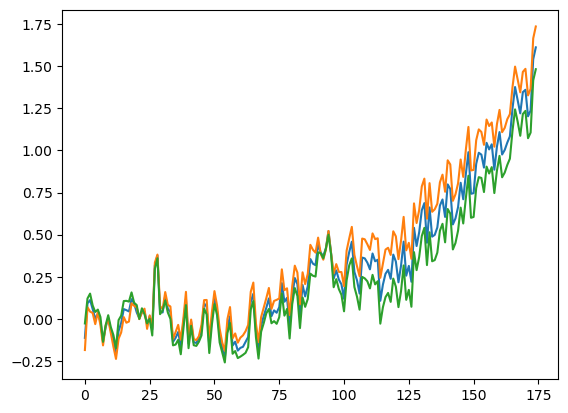

In [9]:
gmst_s_new_baseline = ds_gmst_s - ds_gmst_s.sel(time=slice("1850-01-01", "1900-12-31")).mean(dim="time")

for var in ["surface_temperature_anomaly_median", "surface_temperature_anomaly_lower", "surface_temperature_anomaly_upper"]:
    plt.plot(gmst_s_new_baseline[var].groupby("time.year").mean())
    

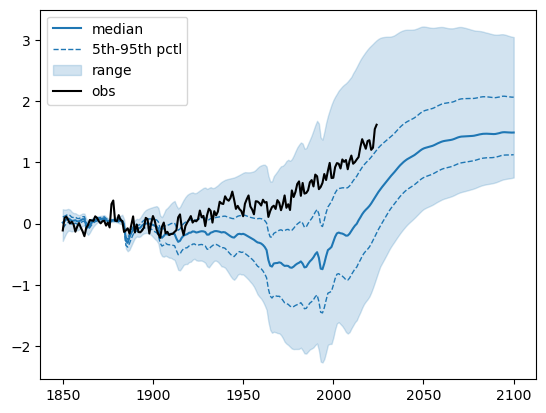

In [10]:
# quick plot of prior - no temperature or ERFaci constraint
plt.plot(fair_new_baseline.year, fair_new_baseline.median(dim="ensemble"), label="median")
plt.plot(fair_new_baseline.year, fair_new_baseline.quantile(0.05, dim="ensemble"),
        ls="--", color="C0", lw=1)
plt.plot(fair_new_baseline.year, fair_new_baseline.quantile(0.95, dim="ensemble"),
        ls="--", color="C0", lw=1, label="5th-95th pctl")
plt.fill_between(fair_new_baseline.year, fair_new_baseline.min(dim="ensemble"), fair_new_baseline.max(dim="ensemble"),
                color="C0", alpha=0.2, label="range")
plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.legend()
plt.show()


In [80]:
# hardcode these #'s from original fair script

ar6 = [0.8693932966310658, 1.280606703368934]
fair_ar6 = fair_new_baseline.sel(year=slice(2011, 2020)).mean(dim="year") - fair_new_baseline.sel(year=slice(1850, 1900)).mean(dim="year")
fair_meet_ar6 = fair_new_baseline.where((fair_ar6 <= ar6[1]) & (fair_ar6 >= ar6[0]), drop=True)


In [81]:
rate_8020 = (gmst_e_new_baseline.sel(year=2020) - gmst_e_new_baseline.sel(year=1980))/(2020-1980)

fair_rate_8020 = (fair_new_baseline.sel(year=2020) - fair_new_baseline.sel(year=1980))/(2020-1980)
fair_meet_rate8020 = fair_new_baseline.where((fair_rate_8020 <= rate_8020.quantile(0.95)) & 
                                             (fair_rate_8020 >= rate_8020.quantile(0.05)), drop=True)


In [82]:
fair_meet_ar6_8020_ensn = [x for x in fair_meet_rate8020.ensemble.values if x in fair_meet_ar6.ensemble.values]
fair_meet_ar6_8020 = ds_all["temps"].sel(ensemble=fair_meet_ar6_8020_ensn)

print(len(fair_meet_ar6_8020))


0


(array([3., 2., 4., 9., 7., 9., 6., 5., 4., 5.]),
 array([-0.50388766, -0.43790643, -0.37192519, -0.30594395, -0.23996272,
        -0.17398148, -0.10800025, -0.04201901,  0.02396222,  0.08994346,
         0.1559247 ]),
 <BarContainer object of 10 artists>)

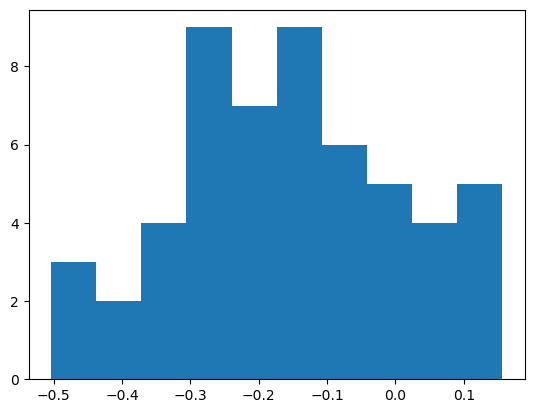

In [16]:
plt.hist(ds_all["ERFaci"].sel(ensemble=fair_meet_ar6_8020.ensemble))

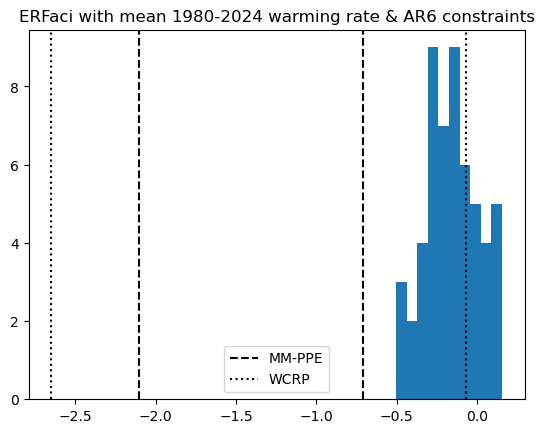

In [17]:
erfaci_meet_ar6_8020 = ds_all["ERFaci"].sel(ensemble=fair_meet_ar6_8020.ensemble)

plt.hist(erfaci_meet_ar6_8020)
plt.title("ERFaci with mean 1980-2024 warming rate & AR6 constraints")
plt.axvline(mmppe_erfaci[0], color="k", ls="--", label="MM-PPE")
plt.axvline(mmppe_erfaci[1], color="k", ls="--")
plt.axvline(-2.65, color="k", label="WCRP", ls=":")
plt.axvline(-0.07, color="k", ls=":")
plt.legend()
plt.show()


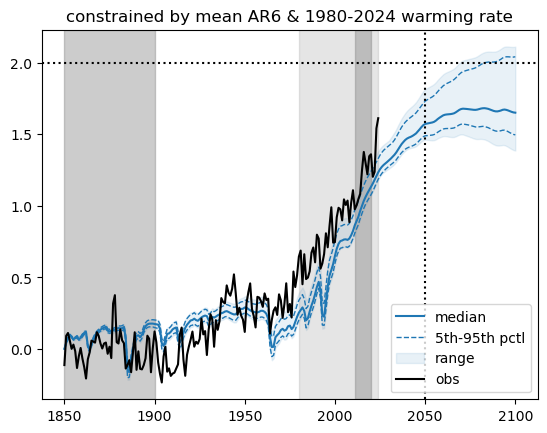

In [19]:
# AR6 + warming rate constraint
plt.plot(fair_meet_ar6_8020.year, fair_meet_ar6_8020.median(dim="ensemble"), label="median")
plt.plot(fair_meet_ar6_8020.year, fair_meet_ar6_8020.quantile(0.05, dim="ensemble"),
        ls="--", color="C0", lw=1)
plt.plot(fair_meet_ar6_8020.year, fair_meet_ar6_8020.quantile(0.95, dim="ensemble"),
        ls="--", color="C0", lw=1, label="5th-95th pctl")
plt.fill_between(fair_meet_ar6_8020.year, fair_meet_ar6_8020.min(dim="ensemble"), 
                 fair_meet_ar6_8020.max(dim="ensemble"),
                color="C0", alpha=0.1, label="range")
plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("constrained by mean AR6 & 1980-2024 warming rate")
plt.axvspan(1980, 2024, color="grey", alpha=0.2)
plt.axvspan(1850, 1900, color="grey", alpha=0.4)
plt.axvspan(2011, 2020, color="grey", alpha=0.4)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.legend()
plt.show()


In [16]:
obs_1950 = gmst_e_new_baseline.sel(year=slice(1950, 1959)).mean(dim="year")

fair_1950 = fair_new_baseline.sel(year=slice(1950, 1959)).mean(dim="year")
fair_meet_1950 = fair_new_baseline.where((fair_1950 >= obs_1950.quantile(0.05)) & 
                                         (fair_1950 <= obs_1950.quantile(0.95)), drop=True)


In [17]:
fair_meet_ar6_1950_ensn = [x for x in fair_meet_1950.ensemble.values if x in fair_meet_ar6.ensemble.values]
fair_meet_ar6_1950 = ds_all["temps"].sel(ensemble=fair_meet_ar6_1950_ensn)


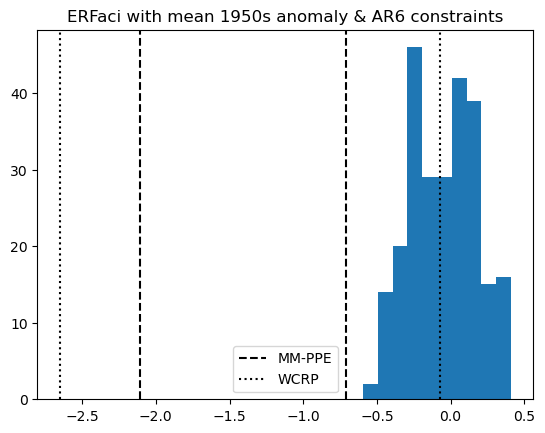

In [18]:
erfaci_meet_ar6_1950 = ds_all["ERFaci"].sel(ensemble=fair_meet_ar6_1950.ensemble)

plt.hist(erfaci_meet_ar6_1950)
plt.title("ERFaci with mean 1950s anomaly & AR6 constraints")
plt.axvline(mmppe_erfaci[0], color="k", ls="--", label="MM-PPE")
plt.axvline(mmppe_erfaci[1], color="k", ls="--")
plt.axvline(-2.65, color="k", label="WCRP", ls=":")
plt.axvline(-0.07, color="k", ls=":")
plt.legend()
plt.show()


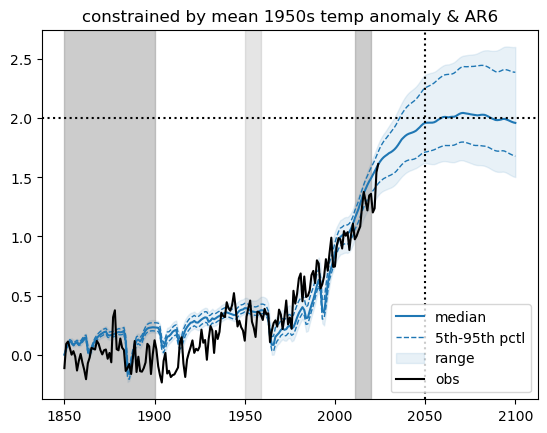

In [23]:

plt.plot(fair_meet_ar6_1950.year, fair_meet_ar6_1950.median(dim="ensemble"), label="median")
plt.plot(fair_meet_ar6_1950.year, fair_meet_ar6_1950.quantile(0.05, dim="ensemble"),
        ls="--", color="C0", lw=1)
plt.plot(fair_meet_ar6_1950.year, fair_meet_ar6_1950.quantile(0.95, dim="ensemble"),
        ls="--", color="C0", lw=1, label="5th-95th pctl")
plt.fill_between(fair_meet_ar6_1950.year, fair_meet_ar6_1950.min(dim="ensemble"), 
                 fair_meet_ar6_1950.max(dim="ensemble"),
                color="C0", alpha=0.1, label="range")
plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("constrained by mean 1950s temp anomaly & AR6")
plt.axvspan(1950, 1959, color="grey", alpha=0.2)
plt.axvspan(2011, 2020, color="grey", alpha=0.4)
plt.axvspan(1850, 1900, color="grey", alpha=0.4)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.legend()
plt.show()


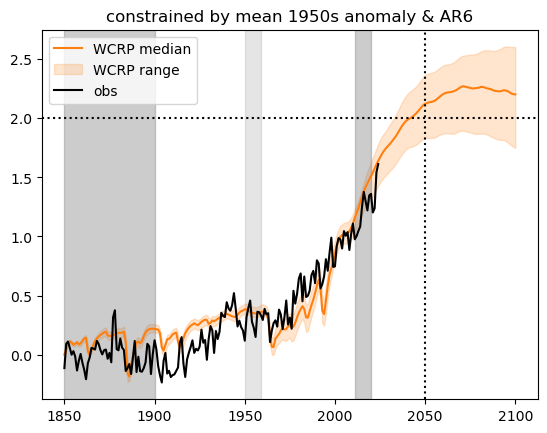

In [24]:
fair_meet_1950_ar6_wcrp = fair_meet_ar6_1950.where((erfaci_meet_ar6_1950 <= -0.07) & (erfaci_meet_ar6_1950 >= -2.65), drop=True)

plt.plot(fair_meet_1950_ar6_wcrp.year, fair_meet_1950_ar6_wcrp.median(dim="ensemble"), label="WCRP median", color="C1")
plt.fill_between(fair_meet_1950_ar6_wcrp.year, fair_meet_1950_ar6_wcrp.min(dim="ensemble"), 
                 fair_meet_1950_ar6_wcrp.max(dim="ensemble"),
                color="C1", alpha=0.2, label="WCRP range")

plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("constrained by mean 1950s anomaly & AR6")
plt.axvspan(1950, 1959, color="grey", alpha=0.2)
plt.axvspan(2011, 2020, color="grey", alpha=0.4)
plt.axvspan(1850, 1900, color="grey", alpha=0.4)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.legend()
plt.show()


In [25]:
ftemp_meet_ar6_1950_wcrp = ds_all["temps"].sel(year=2050, ensemble=erfaci_meet_ar6_1950.ensemble)

print(ftemp_meet_ar6_1950_wcrp.where(ftemp_meet_ar6_1950_wcrp >= 2).count() / len(ftemp_meet_ar6_1950_wcrp.ensemble) * 100)


<xarray.DataArray 'temps' ()> Size: 8B
array(44.44444444)
Coordinates:
    year     int64 8B 2050


In [52]:
obs_6070 = gmst_e_new_baseline.sel(year=slice(1960, 1979)).mean(dim="year")

fair_6070 = fair_new_baseline.sel(year=slice(1960, 1979)).mean(dim="year")
fair_meet_6070 = fair_new_baseline.where((fair_6070 >= obs_6070.quantile(0.05)) & 
                                         (fair_6070 <= obs_6070.quantile(0.95)), drop=True)


In [53]:
fair_meet_ar6_6070_ensn = [x for x in fair_meet_6070.ensemble.values if x in fair_meet_ar6.ensemble.values]
fair_meet_ar6_6070 = ds_all["temps"].sel(ensemble=fair_meet_ar6_6070_ensn)



In [54]:
fair_meet_ar6.ensemble

<xarray.DataArray 'ensemble' (ensemble: 3719)> Size: 30kB
array([    17,     41,     47, ..., 129830, 129927, 129982])
Coordinates:
  * ensemble  (ensemble) int64 30kB 17 41 47 54 ... 129775 129830 129927 129982

In [55]:
fair_meet_6070.ensemble

<xarray.DataArray 'ensemble' (ensemble: 114)> Size: 912B
array([  1631,   4666,   5338,   5412,   5485,   5734,   5801,   5848,   6198,
         6399,   6535,   6631,   6775,   7426,   7437,   7476,   7580,   7601,
         7721,   7818,   7840,   8079,   8220,   8240,   8304,   8772,   8930,
         8961,   9344,   9453,   9571,   9683,   9767,  15143,  15338,  15412,
        15485,  15734,  15797,  15801,  15848,  15872,  15913,  16163,  16198,
        16399,  16535,  16631,  17145,  17224,  17426,  17437,  17476,  17580,
        17601,  17666,  17721,  17818,  17840,  18079,  18220,  18240,  18304,
        18317,  18589,  18736,  18772,  18869,  18930,  19344,  19381,  19448,
        19453,  19477,  19571,  19683,  19767,  31809,  41631,  44666,  49666,
        55545,  55848,  56631,  56777,  56809,  57580,  57721,  57807,  58772,
        58961,  59453,  59666,  64666,  66631,  69666,  74666,  76809,  80545,
        81631,  81809,  82807,  83772,  84666,  86777,  88961,  89666,  99666,
       101631, 109666, 114666, 119666, 124666, 129666])
Coordinates:
  * ensemble  (ensemble) int64 912B 1631 4666 5338 5412 ... 119666 124666 129666

In [56]:
fair_meet_ar6_6070

<xarray.DataArray 'temps' (ensemble: 0, year: 251)> Size: 0B
array([], shape=(0, 251), dtype=float64)
Coordinates:
  * year      (year) int64 2kB 1850 1851 1852 1853 1854 ... 2097 2098 2099 2100
  * ensemble  (ensemble) int64 0B

In [31]:
# hardcode these #'s from original fair script

ar6 = [0.8693932966310658, 1.280606703368934]
fair_ar6 = fair_new_baseline.sel(year=slice(2011, 2020)).mean(dim="year") - fair_new_baseline.sel(year=slice(1850, 1900)).mean(dim="year")
fair_meet_ar6 = fair_new_baseline.where((fair_ar6 <= ar6[1]) & (fair_ar6 >= ar6[0]), drop=True)


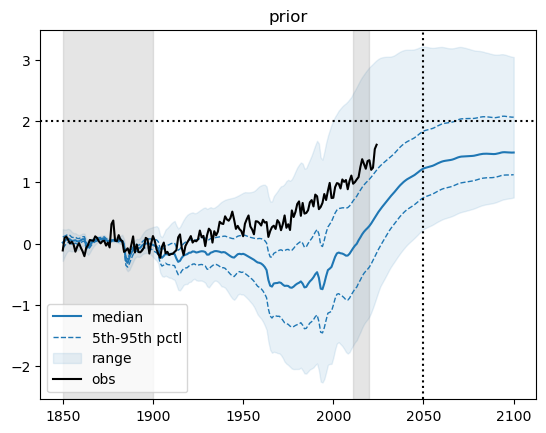

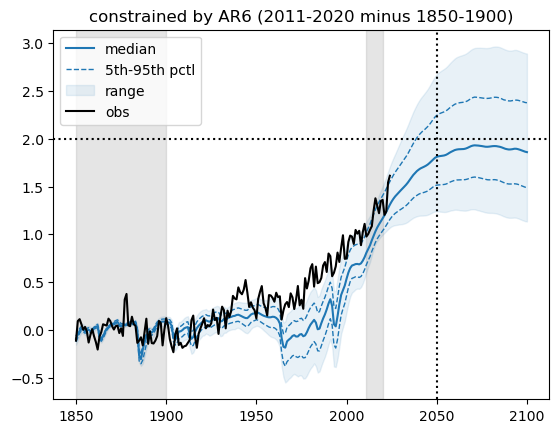

In [32]:
# quick plot of prior - no temperature or ERFaci constraint
plt.plot(fair_new_baseline.year, fair_new_baseline.median(dim="ensemble"), label="median")
plt.plot(fair_new_baseline.year, fair_new_baseline.quantile(0.05, dim="ensemble"),
        ls="--", color="C0", lw=1)
plt.plot(fair_new_baseline.year, fair_new_baseline.quantile(0.95, dim="ensemble"),
        ls="--", color="C0", lw=1, label="5th-95th pctl")
plt.fill_between(fair_new_baseline.year, fair_new_baseline.min(dim="ensemble"), fair_new_baseline.max(dim="ensemble"),
                color="C0", alpha=0.1, label="range")
plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("prior")
plt.axvspan(1850, 1900, color="grey", alpha=0.2)
plt.axvspan(2011, 2020, color="gray", alpha=0.2)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.legend()
plt.show()

# AR6 constraint
plt.plot(fair_meet_ar6.year, fair_meet_ar6.median(dim="ensemble"), label="median")
plt.plot(fair_meet_ar6.year, fair_meet_ar6.quantile(0.05, dim="ensemble"),
        ls="--", color="C0", lw=1)
plt.plot(fair_meet_ar6.year, fair_meet_ar6.quantile(0.95, dim="ensemble"),
        ls="--", color="C0", lw=1, label="5th-95th pctl")
plt.fill_between(fair_meet_ar6.year, fair_meet_ar6.min(dim="ensemble"), 
                 fair_meet_ar6.max(dim="ensemble"),
                color="C0", alpha=0.1, label="range")
plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("constrained by AR6 (2011-2020 minus 1850-1900)")
plt.axvspan(1850, 1900, color="grey", alpha=0.2)
plt.axvspan(2011, 2020, color="gray", alpha=0.2)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.legend()
plt.show()


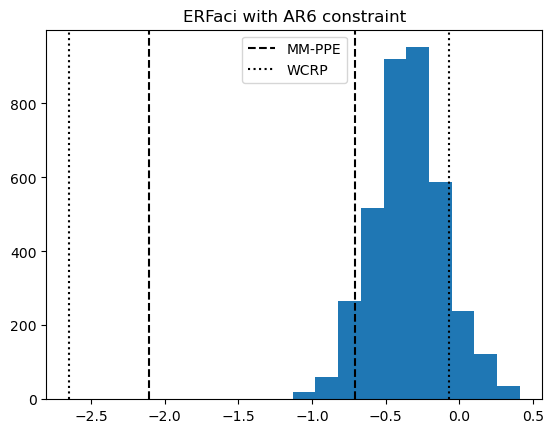

In [33]:
erfaci_meet_ar6 = ds_all["ERFaci"].sel(ensemble=fair_meet_ar6.ensemble)

plt.hist(erfaci_meet_ar6)
plt.title("ERFaci with AR6 constraint")
plt.axvline(mmppe_erfaci[0], color="k", ls="--", label="MM-PPE")
plt.axvline(mmppe_erfaci[1], color="k", ls="--")
plt.axvline(-2.65, color="k", label="WCRP", ls=":")
plt.axvline(-0.07, color="k", ls=":")
plt.legend()
plt.show()


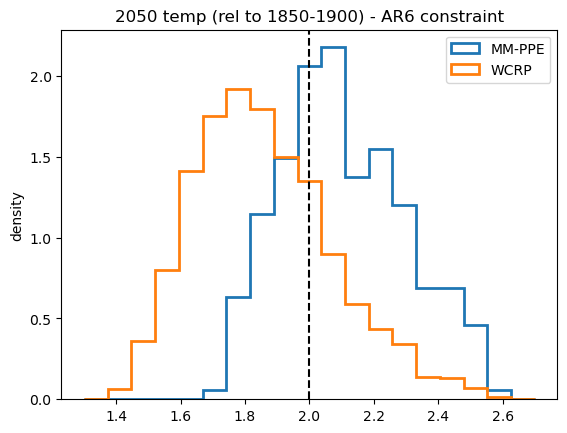

In [34]:
ftemp_meet_ar6_mmppe = fair_meet_ar6.sel(year=2050).where((erfaci_meet_ar6 <= mmppe_erfaci[1]) & (erfaci_meet_ar6 >= mmppe_erfaci[0]), drop=True)
ftemp_meet_ar6_wcrp = fair_meet_ar6.sel(year=2050).where((erfaci_meet_ar6 <= -0.07) & (erfaci_meet_ar6 >= -2.65), drop=True)

bins = np.linspace(1.3, 2.7, 20)
plt.hist(ftemp_meet_ar6_mmppe, histtype="step", label="MM-PPE", density=True, lw=2, bins=bins)
plt.hist(ftemp_meet_ar6_wcrp, histtype="step", label="WCRP", density=True, lw=2, bins=bins)
plt.title("2050 temp (rel to 1850-1900) - AR6 constraint")
plt.ylabel("density")
plt.axvline(2, color="k", ls="--")
plt.legend()
plt.show()


I'm still bothered that we're getting slightly different #'s when constraining this way... be sure to be very careful with that... (but qualitatively the pattern hasn't changed)

In [35]:
print(ftemp_meet_ar6_wcrp.where(ftemp_meet_ar6_wcrp >= 2).count() / len(ftemp_meet_ar6_wcrp.ensemble) * 100)
print(ftemp_meet_ar6_mmppe.where(ftemp_meet_ar6_mmppe >= 2).count() / len(ftemp_meet_ar6_mmppe.ensemble) * 100)


<xarray.DataArray 'temps' ()> Size: 8B
array(24.31930693)
Coordinates:
    year     int64 8B 2050
<xarray.DataArray 'temps' ()> Size: 8B
array(69.19831224)
Coordinates:
    year     int64 8B 2050


#### 1950s + >2000

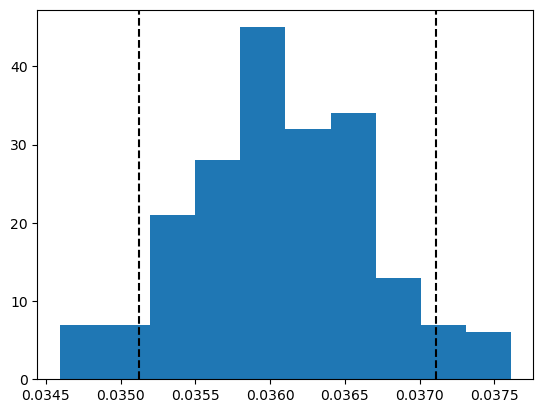

In [19]:
rate_2000 = (gmst_e_new_baseline.sel(year=2024) - gmst_e_new_baseline.sel(year=2000))/24

plt.hist(rate_2000)
plt.axvline(rate_2000.quantile(0.05), ls="--", color="k")
plt.axvline(rate_2000.quantile(0.95), ls="--", color="k")
plt.show()


In [20]:
fair_rate_2000 = (fair_new_baseline.sel(year=2024) - fair_new_baseline.sel(year=2000))/24
fair_meet_rate2000 = fair_new_baseline.where((fair_rate_2000 <= rate_2000.quantile(0.95)) & 
                                             (fair_rate_2000 >= rate_2000.quantile(0.05)), drop=True)


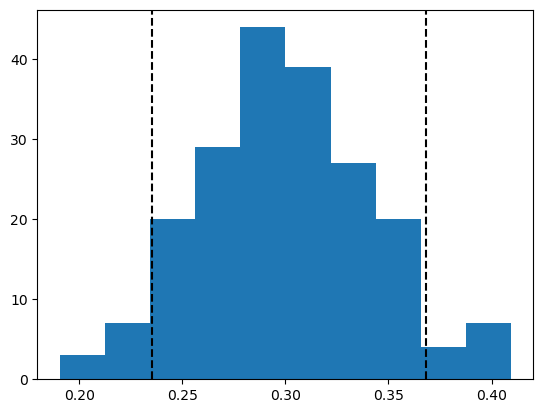

In [23]:
obs_1950 = gmst_e_new_baseline.sel(year=slice(1950, 1959)).mean(dim="year")

plt.hist(obs_1950)
plt.axvline(obs_1950.quantile(0.05), ls="--", color="k")
plt.axvline(obs_1950.quantile(0.95), ls="--", color="k")
plt.show()


In [24]:
fair_1950 = fair_new_baseline.sel(year=slice(1950, 1959)).mean(dim="year")
fair_meet_1950 = fair_new_baseline.where((fair_1950 >= obs_1950.quantile(0.05)) & 
                                         (fair_1950 <= obs_1950.quantile(0.95)), drop=True)


In [33]:
ensn_meet_both = [x for x in fair_meet_1950.ensemble.values if x in fair_meet_rate2000.ensemble.values]
len(ensn_meet_both)


70

In [34]:
fair_meet_both = fair_new_baseline.sel(ensemble=ensn_meet_both)


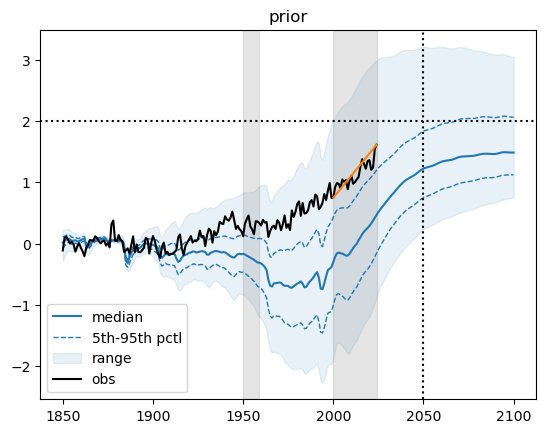

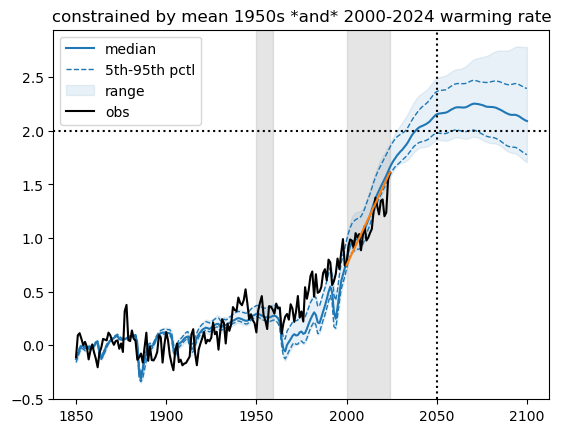

In [35]:
# quick plot of prior - no temperature or ERFaci constraint
plt.plot(fair_new_baseline.year, fair_new_baseline.median(dim="ensemble"), label="median")
plt.plot(fair_new_baseline.year, fair_new_baseline.quantile(0.05, dim="ensemble"),
        ls="--", color="C0", lw=1)
plt.plot(fair_new_baseline.year, fair_new_baseline.quantile(0.95, dim="ensemble"),
        ls="--", color="C0", lw=1, label="5th-95th pctl")
plt.fill_between(fair_new_baseline.year, fair_new_baseline.min(dim="ensemble"), fair_new_baseline.max(dim="ensemble"),
                color="C0", alpha=0.1, label="range")
plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("prior")
plt.axvspan(1950, 1959, color="grey", alpha=0.2)
plt.plot((2000, 2024), (gmst_new_baseline.sel(year=2000), gmst_new_baseline.sel(year=2024)))
plt.axvspan(2000, 2024, color="grey", alpha=0.2)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.legend()
plt.show()

# Watson-Parris (2025) constraint
plt.plot(fair_meet_both.year, fair_meet_both.median(dim="ensemble"), label="median")
plt.plot(fair_meet_both.year, fair_meet_both.quantile(0.05, dim="ensemble"),
        ls="--", color="C0", lw=1)
plt.plot(fair_meet_both.year, fair_meet_both.quantile(0.95, dim="ensemble"),
        ls="--", color="C0", lw=1, label="5th-95th pctl")
plt.fill_between(fair_meet_both.year, fair_meet_both.min(dim="ensemble"), 
                 fair_meet_both.max(dim="ensemble"),
                color="C0", alpha=0.1, label="range")
plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("constrained by mean 1950s *and* 2000-2024 warming rate")
plt.axvspan(1950, 1959, color="grey", alpha=0.2)
plt.plot((2000, 2024), (gmst_new_baseline.sel(year=2000), gmst_new_baseline.sel(year=2024)))
plt.axvspan(2000, 2024, color="grey", alpha=0.2)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.legend()
plt.show()


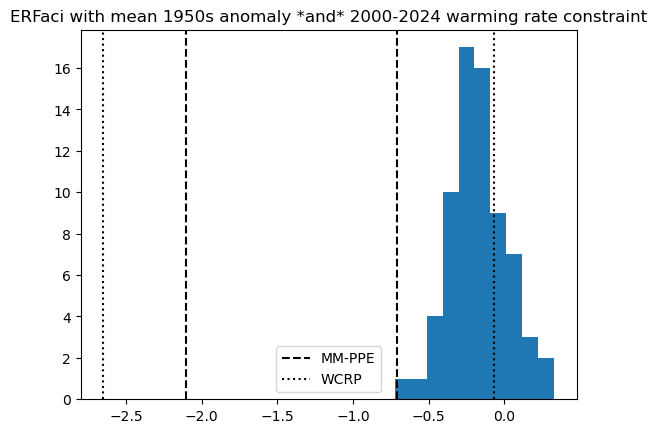

-0.7233780436938707


In [36]:
erfaci_meet_both = ds_all["ERFaci"].sel(ensemble=fair_meet_both.ensemble)

plt.hist(erfaci_meet_both)
plt.title("ERFaci with mean 1950s anomaly *and* 2000-2024 warming rate constraint")
plt.axvline(mmppe_erfaci[0], color="k", ls="--", label="MM-PPE")
plt.axvline(mmppe_erfaci[1], color="k", ls="--")
plt.axvline(-2.65, color="k", label="WCRP", ls=":")
plt.axvline(-0.07, color="k", ls=":")
plt.legend()
plt.show()

print(erfaci_meet_both.min().values)


In [89]:
ftemp_meet_both_wcrp

<xarray.DataArray 'temps' (ensemble: 51)> Size: 408B
array([2.23809931, 2.12311064, 2.15691566, 2.180257  , 2.24641912,
       2.13127518, 2.16884879, 2.0711214 , 2.08700099, 2.15310556,
       2.2316146 , 2.19493532, 2.33369084, 2.20195704, 2.30198765,
       2.19831346, 2.09924012, 2.19393558, 2.12069962, 2.26159529,
       2.20975305, 2.25777589, 2.29858121, 2.32681697, 2.19003563,
       2.21221181, 2.39025144, 2.1824765 , 2.14142669, 2.24331832,
       2.13134959, 2.20147845, 2.05958574, 2.49323365, 2.34648977,
       2.16596504, 2.10337866, 2.10506119, 2.14492289, 2.40987189,
       2.38417318, 2.07719016, 2.13203429, 2.1669287 , 2.17551022,
       2.1126067 , 2.20873736, 2.11069509, 2.1510167 , 2.2607813 ,
       2.08840916])
Coordinates:
    year      int64 8B 2050
  * ensemble  (ensemble) int64 408B 5007 5488 5605 6064 ... 84397 101652 103977

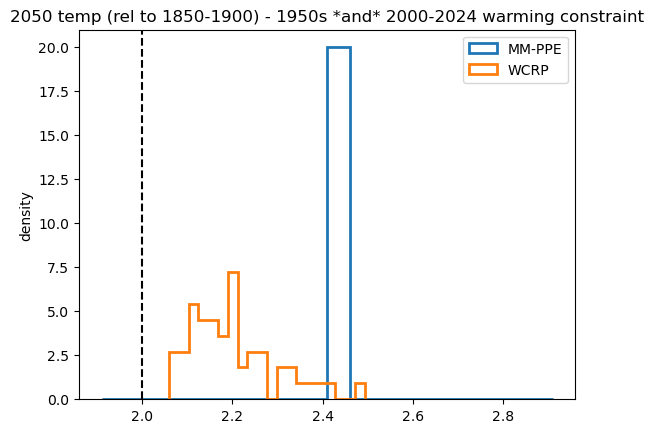

In [37]:
ftemp_meet_both_mmppe = fair_meet_both.sel(year=2050).where((erfaci_meet_both <= mmppe_erfaci[1]) & (erfaci_meet_both >= mmppe_erfaci[0]), drop=True)
ftemp_meet_both_wcrp = fair_meet_both.sel(year=2050).where((erfaci_meet_both <= -0.07) & (erfaci_meet_both >= -2.65), drop=True)

bins = 20#np.linspace(1.3, 2.7, 20)
if len(ftemp_meet_both_mmppe) > 0:
    plt.hist(ftemp_meet_both_mmppe, histtype="step", label="MM-PPE", density=True, lw=2, bins=bins)
plt.hist(ftemp_meet_both_wcrp, histtype="step", label="WCRP", density=True, lw=2, bins=bins, color="C1")
plt.title("2050 temp (rel to 1850-1900) - 1950s *and* 2000-2024 warming constraint")
plt.ylabel("density")
plt.axvline(2, color="k", ls="--")
plt.legend()
plt.show()


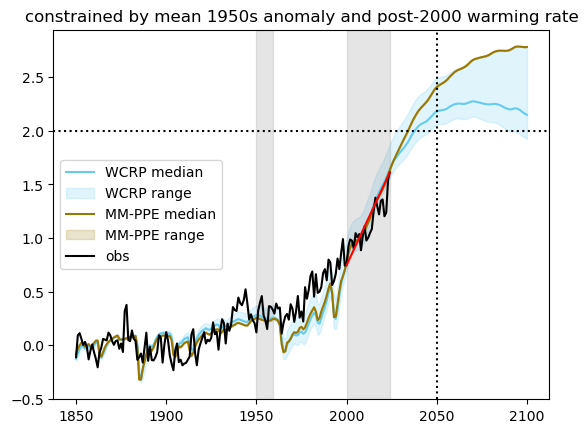

In [44]:
fair_meet_both_mmppe = fair_meet_both.where((erfaci_meet_both <= mmppe_erfaci[1]) & (erfaci_meet_both >= mmppe_erfaci[0]), drop=True)
fair_meet_both_wcrp = fair_meet_both.where((erfaci_meet_both <= -0.07) & (erfaci_meet_both >= -2.65), drop=True)

plt.plot(fair_meet_both_wcrp.year, fair_meet_both_wcrp.median(dim="ensemble"), label="WCRP median", color="#66CCEE")
plt.fill_between(fair_meet_both_wcrp.year, fair_meet_both_wcrp.min(dim="ensemble"), 
                 fair_meet_both_wcrp.max(dim="ensemble"),
                color="#66CCEE", alpha=0.2, label="WCRP range")

plt.plot(fair_meet_both_mmppe.year, fair_meet_both_mmppe.median(dim="ensemble"), label="MM-PPE median", color="#997700")
plt.fill_between(fair_meet_both_mmppe.year, fair_meet_both_mmppe.min(dim="ensemble"), 
                 fair_meet_both_mmppe.max(dim="ensemble"),
                color="#997700", alpha=0.2, label="MM-PPE range")

plt.plot(gmst_new_baseline.year, gmst_new_baseline, color="k", label="obs")
plt.title("constrained by mean 1950s anomaly and post-2000 warming rate")
plt.axvspan(1950, 1959, color="grey", alpha=0.2)
plt.axvspan(2000, 2024, color="grey", alpha=0.2)
plt.axhline(2, color="k", ls=":")
plt.axvline(2050, color="k", ls=":")
plt.plot((2000, 2024), (gmst_new_baseline.sel(year=2000), gmst_new_baseline.sel(year=2024)), color="red")
plt.legend()
plt.show()


In [40]:
ftemp_meet_both_mmppe

<xarray.DataArray 'temps' (ensemble: 1)> Size: 8B
array([2.40987189])
Coordinates:
    year      int64 8B 2050
  * ensemble  (ensemble) int64 8B 55276

In [67]:
ftemp_meet_both_wcrp.min().values

array(2.05958574)

In [38]:
# 100% chance of exceeding....
